Cargando modelos Fase 1...
Cargando modelos Fase 2 - Gatos...
Cargando modelos Fase 2 - Perros...
Modelos cargados correctamente.



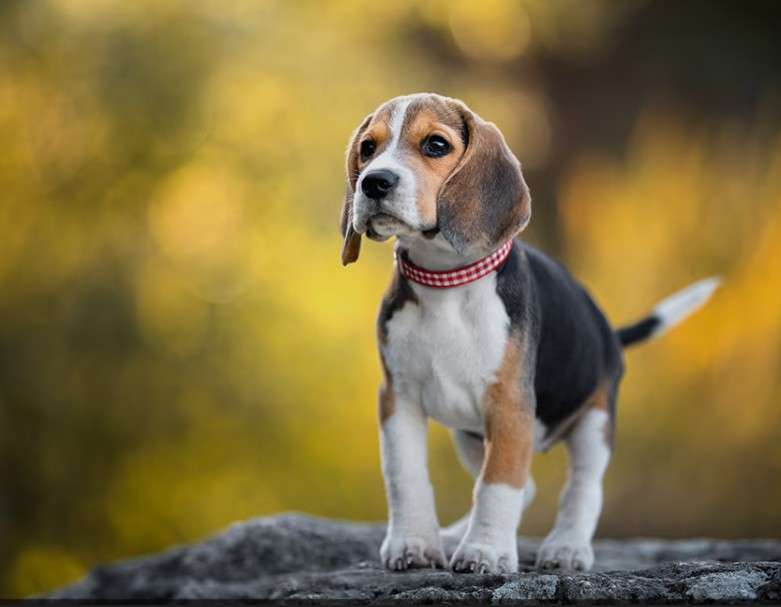

In [4]:
########################################################################
########## DEMO NOTEBOOK - DASHBOARD PREMIUM FINAL ######################
########################################################################

import numpy as np
import pandas as pd
import tensorflow as tf

from IPython.display import display, HTML
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ============================================================
# RUTAS DE MODELOS
# ============================================================

# -------- FASE 1: PERRO / GATO --------
ruta_modelo_fase1_3cnn = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\3capas_modelo_fase1_perro_gato.keras"
ruta_modelo_fase1_4cnn = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\4capas_modelo_fase1_perro_gato.keras"
ruta_modelo_fase1_5cnn = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\5capas_modelo_fase1_perro_gato.keras"

# -------- FASE 2: GATOS --------
ruta_modelo_gatos_transfer = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\modelo_razas_gatos_TransferLearning.keras"
ruta_modelo_gatos_fine = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\modelo_razas_gatos_FineTuning.keras"

# -------- FASE 2: PERROS --------
ruta_modelo_perros_transfer = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\modelo_razas_perros_TransferLearning.keras"
ruta_modelo_perros_fine = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\modelo_razas_perros_FineTuning.keras"

# -------- IMAGEN DEMO --------
ruta_imagen = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\OXFORD\IMAGENES PRUEBA\1.jpg"

# ============================================================
# PARÁMETROS
# ============================================================
IMG_HEIGHT = 224
IMG_WIDTH = 224
THRESHOLD_FASE1 = 0.37

# ============================================================
# CLASES
# ============================================================
clases_gatos = [
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair",
    "Egyptian", "Maine", "Persian", "Ragdoll", "Russian Blue",
    "Siamese", "Sphynx"
]

clases_perros = [
    "American bulldog", "American pitbull", "Basset hound", "Beagle",
    "Boxer", "Chihuahua", "English cocker", "English setter", "German",
    "Great pyrenees", "Havanese", "Japanese chin", "Keeshond",
    "Leonberger", "Miniature pinscher", "Newfoundland", "Pomeranian",
    "Pug", "Saint bernard", "Samoyed", "Scottish", "Shiba",
    "Staffordshire", "Wheaten", "Yorkshire"
]

# ============================================================
# CARGAR MODELOS
# ============================================================
print("Cargando modelos Fase 1...")
modelo_fase1_3cnn = load_model(ruta_modelo_fase1_3cnn)
modelo_fase1_4cnn = load_model(ruta_modelo_fase1_4cnn)
modelo_fase1_5cnn = load_model(ruta_modelo_fase1_5cnn)

print("Cargando modelos Fase 2 - Gatos...")
modelo_gatos_transfer = load_model(
    ruta_modelo_gatos_transfer,
    custom_objects={"preprocess_input": preprocess_input},
    compile=False
)
modelo_gatos_fine = load_model(
    ruta_modelo_gatos_fine,
    custom_objects={"preprocess_input": preprocess_input},
    compile=False
)

print("Cargando modelos Fase 2 - Perros...")
modelo_perros_transfer = load_model(
    ruta_modelo_perros_transfer,
    custom_objects={"preprocess_input": preprocess_input},
    compile=False
)
modelo_perros_fine = load_model(
    ruta_modelo_perros_fine,
    custom_objects={"preprocess_input": preprocess_input},
    compile=False
)

print("Modelos cargados correctamente.")

# ============================================================
# FUNCIONES
# ============================================================
def preparar_imagen_fase1(ruta_imagen):
    img = tf.keras.utils.load_img(ruta_imagen, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array.astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array

def preparar_imagen_fase2(ruta_imagen):
    img = tf.keras.utils.load_img(ruta_imagen, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def predecir_fase1(modelo, img_array, threshold=THRESHOLD_FASE1):
    prob_gato = float(modelo.predict(img_array, verbose=0)[0][0])
    if prob_gato >= threshold:
        return "GATO", prob_gato
    return "PERRO", 1 - prob_gato

def predecir_razas(modelo, img_array, clases):
    probs = modelo.predict(img_array, verbose=0)[0]
    idx = int(np.argmax(probs))
    pred = clases[idx]
    conf = float(probs[idx])
    return pred, conf, probs

def obtener_top5(probabilidades, clases):
    idx_top5 = np.argsort(probabilidades)[::-1][:5]
    data = []
    for i, idx in enumerate(idx_top5, start=1):
        data.append({
            "Top": i,
            "Raza": clases[idx],
            "Probabilidad": probabilidades[idx]
        })
    return pd.DataFrame(data)

def _hide_index_safe(styler):
    try:
        return styler.hide(axis="index")
    except Exception:
        try:
            return styler.hide_index()
        except Exception:
            return styler

def estilo_tabla_resumen(df):
    confianza_vals = []
    for col in df.columns:
        val = df.loc["Confianza", col]
        confianza_vals.append(float(str(val).replace("%", "")))
    max_conf = max(confianza_vals)

    def color_celdas(val):
        try:
            num = float(str(val).replace("%", ""))
            if abs(num - max_conf) < 1e-9:
                return "background-color: #C6EFCE; color: #006100; font-weight: bold;"
        except Exception:
            pass
        return ""

    styler = (
        df.style
        .set_properties(**{
            "text-align": "center",
            "border": "1px solid #BFBFBF",
            "font-size": "15px"
        })
        .set_table_styles([
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("margin", "0"),
                ("width", "100%")
            ]},
            {"selector": "th", "props": [
                ("background-color", "#D9EAF7"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #BFBFBF"),
                ("padding", "10px")
            ]},
            {"selector": "td", "props": [
                ("padding", "10px"),
                ("border", "1px solid #BFBFBF")
            ]}
        ])
        .map(color_celdas)
    )

    styler = _hide_index_safe(styler)
    return styler

def estilo_top5(df):
    max_prob = df["Probabilidad"].max()

    def resaltar_fila(row):
        if row["Probabilidad"] == max_prob:
            return ["background-color: #C6EFCE; color: #006100; font-weight: bold;"] * len(row)
        return [""] * len(row)

    styler = (
        df.style
        .format({"Probabilidad": lambda x: f"{x*100:.2f}%"})
        .set_properties(**{
            "text-align": "center",
            "border": "1px solid #BFBFBF",
            "font-size": "14px"
        })
        .set_table_styles([
            {"selector": "table", "props": [
                ("border-collapse", "collapse"),
                ("margin", "0"),
                ("width", "100%")
            ]},
            {"selector": "th", "props": [
                ("background-color", "#D9EAF7"),
                ("color", "black"),
                ("font-weight", "bold"),
                ("text-align", "center"),
                ("border", "1px solid #BFBFBF"),
                ("padding", "10px")
            ]},
            {"selector": "td", "props": [
                ("padding", "10px"),
                ("border", "1px solid #BFBFBF")
            ]}
        ])
        .apply(resaltar_fila, axis=1)
    )

    styler = _hide_index_safe(styler)
    return styler

def styler_to_html(styler):
    try:
        return styler.to_html()
    except Exception:
        return styler.render()

# ============================================================
# PREDICCIÓN
# ============================================================
img_mostrar, img_fase1 = preparar_imagen_fase1(ruta_imagen)
img_fase2 = preparar_imagen_fase2(ruta_imagen)

# -------- FASE 1 --------
pred_3, conf_3 = predecir_fase1(modelo_fase1_3cnn, img_fase1)
pred_4, conf_4 = predecir_fase1(modelo_fase1_4cnn, img_fase1)
pred_5, conf_5 = predecir_fase1(modelo_fase1_5cnn, img_fase1)

# ============================================================
# NUEVA LÓGICA: GANA EL MODELO CON MAYOR CONFIANZA
# ============================================================
resultados_fase1 = [
    ("3 CNN", pred_3, conf_3),
    ("4 CNN", pred_4, conf_4),
    ("5 CNN", pred_5, conf_5)
]

modelo_fase1_ganador, especie_final, confianza_fase1 = max(
    resultados_fase1,
    key=lambda x: x[2]
)

# -------- FASE 2 --------
if especie_final == "GATO":
    pred_tl, conf_tl, probs_tl = predecir_razas(modelo_gatos_transfer, img_fase2, clases_gatos)
    pred_ft, conf_ft, probs_ft = predecir_razas(modelo_gatos_fine, img_fase2, clases_gatos)
    clases_actuales = clases_gatos
else:
    pred_tl, conf_tl, probs_tl = predecir_razas(modelo_perros_transfer, img_fase2, clases_perros)
    pred_ft, conf_ft, probs_ft = predecir_razas(modelo_perros_fine, img_fase2, clases_perros)
    clases_actuales = clases_perros

# ============================================================
# MODELO GANADOR FASE 2
# ============================================================
if conf_ft >= conf_tl:
    raza_final = pred_ft
    confianza_final = conf_ft
    modelo_ganador = "Fine Tuning"
else:
    raza_final = pred_tl
    confianza_final = conf_tl
    modelo_ganador = "Transfer Learning"


# ============================================================
# TABLAS
# ============================================================
df_fase1 = pd.DataFrame({
    "3 CNN": [pred_3, f"{conf_3*100:.2f}%"],
    "4 CNN": [pred_4, f"{conf_4*100:.2f}%"],
    "5 CNN": [pred_5, f"{conf_5*100:.2f}%"]
}, index=["Predicción", "Confianza"])

df_fase2 = pd.DataFrame({
    "Transfer Learning": [pred_tl, f"{conf_tl*100:.2f}%"],
    "Fine Tuning": [pred_ft, f"{conf_ft*100:.2f}%"]
}, index=["Predicción", "Confianza"])

top5_tl = obtener_top5(probs_tl, clases_actuales)
top5_ft = obtener_top5(probs_ft, clases_actuales)

html_fase1 = styler_to_html(estilo_tabla_resumen(df_fase1))
html_fase2 = styler_to_html(estilo_tabla_resumen(df_fase2))
html_top5_tl = styler_to_html(estilo_top5(top5_tl))
html_top5_ft = styler_to_html(estilo_top5(top5_ft))

# ============================================================
# IMAGEN A HTML
# ============================================================
import base64
from io import BytesIO
from PIL import Image

img_pil = Image.open(ruta_imagen).convert("RGB")
buffer = BytesIO()
img_pil.save(buffer, format="PNG")
img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

# ============================================================
# DASHBOARD HTML FINAL
# ============================================================
dashboard_html = f"""
<style>
.dashboard-container {{
    font-family: Arial, sans-serif;
    color: #1F1F1F;
}}

.dashboard-title {{
    color: #1F4E79;
    font-size: 34px;
    font-weight: bold;
    margin-bottom: 18px;
}}

.top-row {{
    display: flex;
    gap: 28px;
    align-items: flex-start;
}}

.left-panel {{
    width: 42%;
}}

.right-panel {{
    width: 58%;
}}

.card {{
    background: #FFFFFF;
    border: 1px solid #D0D7DE;
    border-radius: 12px;
    padding: 18px;
    margin-bottom: 18px;
    box-shadow: 0 2px 6px rgba(0,0,0,0.05);
}}

.card-title {{
    color: #1F4E79;
    font-size: 20px;
    font-weight: bold;
    margin-bottom: 12px;
}}

.image-box {{
    text-align: center;
}}

.image-box img {{
    max-width: 100%;
    border-radius: 12px;
    border: 1px solid #CFCFCF;
}}

.image-caption {{
    margin-top: 14px;
    font-size: 16px;
    line-height: 1.5;
}}

.image-caption strong {{
    color: #1F4E79;
}}

.bottom-row {{
    display: flex;
    gap: 28px;
    align-items: flex-start;
    margin-top: 6px;
}}

.bottom-col {{
    width: 50%;
}}

.note-box {{
    margin-top: 8px;
    padding: 12px 16px;
    background: #F4F8FB;
    border-left: 5px solid #1F4E79;
    border-radius: 8px;
    font-size: 15px;
}}
</style>

<div class="dashboard-container">
    <div class="dashboard-title">Proyecto Final - Dashboard de Clasificación</div>

    <div class="top-row">

        <div class="left-panel">
            <div class="card image-box">
                <img src="data:image/png;base64,{img_base64}" alt="Imagen de prueba">
                <div class="image-caption">
                    <div><strong>Especie estimada:</strong> {especie_final}</div>
                    <div><strong>Raza estimada:</strong> {raza_final}</div>
                    <div><strong>Modelo ganador:</strong> {modelo_ganador}</div>
                    <div><strong>Confianza final:</strong> {confianza_final*100:.2f}%</div>
                </div>
            </div>
        </div>

        <div class="right-panel">
            <div class="card">
                <div class="card-title">Fase 1 - Clasificación General</div>
                {html_fase1}
            </div>

            <div class="card">
                <div class="card-title">Fase 2 - Clasificación por Raza</div>
                {html_fase2}
            </div>

            <div class="note-box">
                La confianza mostrada corresponde a la probabilidad predicha por el modelo para la clase ganadora.
            </div>
        </div>
    </div>

    <div class="bottom-row">
        <div class="bottom-col">
            <div class="card">
                <div class="card-title">Top 5 Probabilidades - Transfer Learning</div>
                {html_top5_tl}
            </div>
        </div>

        <div class="bottom-col">
            <div class="card">
                <div class="card-title">Top 5 Probabilidades - Fine Tuning</div>
                {html_top5_ft}
            </div>
        </div>
    </div>
</div>
"""

display(HTML(dashboard_html))

Cargando modelos Fase 1...
Cargando modelos Fase 2 - Gatos...
Cargando modelos Fase 2 - Perros...
Modelos cargados correctamente.
Generando gráficas...
Gráficas generadas.



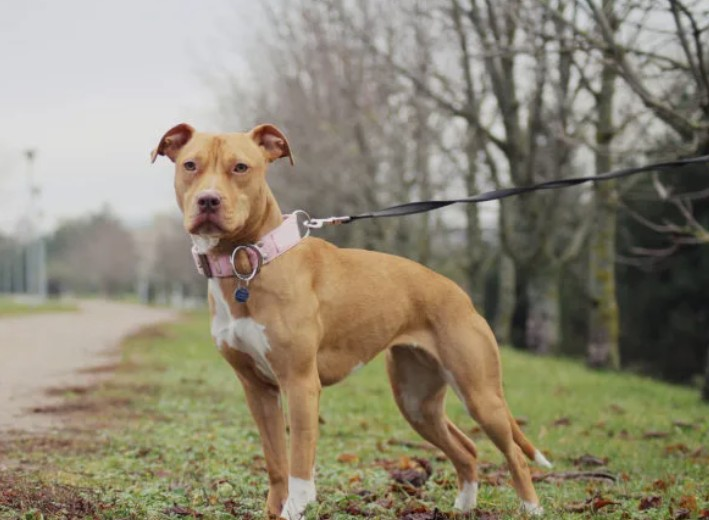
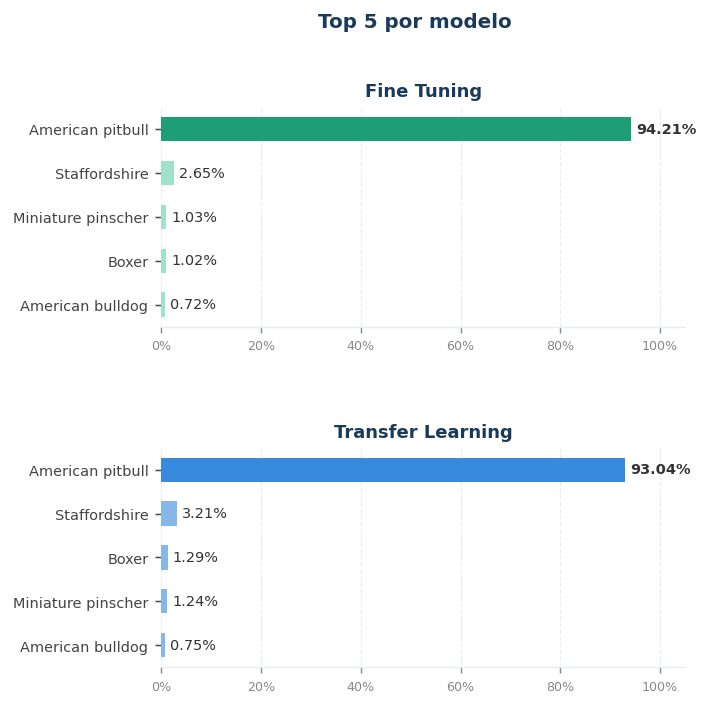
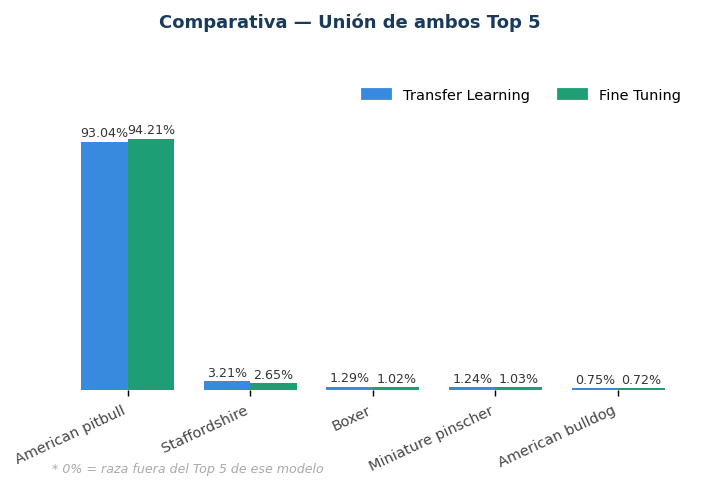

In [3]:
########################################################################
########## DEMO NOTEBOOK - DASHBOARD PREMIUM FINAL ######################
########################################################################

import base64
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from io import BytesIO
from PIL import Image
from collections import Counter
from IPython.display import display, HTML
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

matplotlib.use("Agg")   # backend sin ventana, compatible con Jupyter

# ============================================================
# RUTAS DE MODELOS
# ============================================================

# -------- FASE 1: PERRO / GATO --------
ruta_modelo_fase1_3cnn = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\3capas_modelo_fase1_perro_gato.keras"
ruta_modelo_fase1_4cnn = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\4capas_modelo_fase1_perro_gato.keras"
ruta_modelo_fase1_5cnn = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\5capas_modelo_fase1_perro_gato.keras"

# -------- FASE 2: GATOS --------
ruta_modelo_gatos_transfer = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\modelo_razas_gatos_TransferLearning.keras"
ruta_modelo_gatos_fine     = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\modelo_razas_gatos_FineTuning.keras"

# -------- FASE 2: PERROS --------
ruta_modelo_perros_transfer = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\modelo_razas_perros_TransferLearning.keras"
ruta_modelo_perros_fine     = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\Modelos Mascotas\modelo_razas_perros_FineTuning.keras"

# -------- IMAGEN DE PRUEBA --------
ruta_imagen = r"C:\Users\Oscar Ferreira\OneDrive - AUTO LINEAS AMERICA SA DE CV\Escritorio\MCD\5 - APRENDIZAJE PROFUNDO\PROYECTO FINAL\OXFORD\IMAGENES PRUEBA\12.jpg"

# ============================================================
# PARÁMETROS
# ============================================================
IMG_HEIGHT      = 224
IMG_WIDTH       = 224
THRESHOLD_FASE1 = 0.37

# ============================================================
# CLASES
# ============================================================
clases_gatos = [
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair",
    "Egyptian", "Maine", "Persian", "Ragdoll", "Russian Blue",
    "Siamese", "Sphynx"
]

clases_perros = [
    "American bulldog", "American pitbull", "Basset hound", "Beagle",
    "Boxer", "Chihuahua", "English cocker", "English setter", "German",
    "Great pyrenees", "Havanese", "Japanese chin", "Keeshond",
    "Leonberger", "Miniature pinscher", "Newfoundland", "Pomeranian",
    "Pug", "Saint bernard", "Samoyed", "Scottish", "Shiba",
    "Staffordshire", "Wheaten", "Yorkshire"
]

# ============================================================
# CARGAR MODELOS
# ============================================================
print("Cargando modelos Fase 1...")
modelo_fase1_3cnn = load_model(ruta_modelo_fase1_3cnn)
modelo_fase1_4cnn = load_model(ruta_modelo_fase1_4cnn)
modelo_fase1_5cnn = load_model(ruta_modelo_fase1_5cnn)

print("Cargando modelos Fase 2 - Gatos...")
modelo_gatos_transfer = load_model(
    ruta_modelo_gatos_transfer,
    custom_objects={"preprocess_input": preprocess_input},
    compile=False
)
modelo_gatos_fine = load_model(
    ruta_modelo_gatos_fine,
    custom_objects={"preprocess_input": preprocess_input},
    compile=False
)

print("Cargando modelos Fase 2 - Perros...")
modelo_perros_transfer = load_model(
    ruta_modelo_perros_transfer,
    custom_objects={"preprocess_input": preprocess_input},
    compile=False
)
modelo_perros_fine = load_model(
    ruta_modelo_perros_fine,
    custom_objects={"preprocess_input": preprocess_input},
    compile=False
)

print("Modelos cargados correctamente.")

# ============================================================
# FUNCIONES DE PREPROCESAMIENTO
# ============================================================
def preparar_imagen_fase1(ruta):
    img = tf.keras.utils.load_img(ruta, target_size=(IMG_HEIGHT, IMG_WIDTH))
    arr = tf.keras.utils.img_to_array(img).astype("float32") / 255.0
    arr = np.expand_dims(arr, axis=0)
    return img, arr

def preparar_imagen_fase2(ruta):
    img = tf.keras.utils.load_img(ruta, target_size=(IMG_HEIGHT, IMG_WIDTH))
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    return arr

# ============================================================
# FUNCIONES DE PREDICCIÓN
# ============================================================
def predecir_fase1(modelo, img_array, threshold=THRESHOLD_FASE1):
    prob_gato = float(modelo.predict(img_array, verbose=0)[0][0])
    if prob_gato >= threshold:
        return "GATO", prob_gato
    return "PERRO", 1.0 - prob_gato

def predecir_razas(modelo, img_array, clases):
    probs = modelo.predict(img_array, verbose=0)[0]
    idx   = int(np.argmax(probs))
    return clases[idx], float(probs[idx]), probs

# ============================================================
# FUNCIÓN: TOP 5 CON UNIÓN DE AMBOS MODELOS
# ============================================================
def obtener_top5_union(probs_tl, probs_ft, clases):
    """
    Devuelve la unión de razas de ambos Top 5.
    Si una raza no está en el Top 5 de un modelo devuelve 0.0
    (no significa probabilidad cero, solo que no alcanzó el Top 5).
    """
    idx_top5_tl   = set(np.argsort(probs_tl)[::-1][:5])
    idx_top5_ft   = set(np.argsort(probs_ft)[::-1][:5])
    indices_union = idx_top5_tl | idx_top5_ft

    indices_union = sorted(
        indices_union,
        key=lambda i: max(probs_tl[i], probs_ft[i]),
        reverse=True
    )

    filas = []
    for idx in indices_union:
        filas.append({
            "Raza":              clases[idx],
            "Transfer Learning": float(probs_tl[idx]) if idx in idx_top5_tl else 0.0,
            "Fine Tuning":       float(probs_ft[idx]) if idx in idx_top5_ft else 0.0,
            "en_top5_tl":        idx in idx_top5_tl,
            "en_top5_ft":        idx in idx_top5_ft,
        })
    return filas

# ============================================================
# PREDICCIÓN
# ============================================================
_, img_fase1 = preparar_imagen_fase1(ruta_imagen)
img_fase2    = preparar_imagen_fase2(ruta_imagen)

# -------- FASE 1: REGLA REAL = MAYOR CONFIANZA --------
pred_3, conf_3 = predecir_fase1(modelo_fase1_3cnn, img_fase1)
pred_4, conf_4 = predecir_fase1(modelo_fase1_4cnn, img_fase1)
pred_5, conf_5 = predecir_fase1(modelo_fase1_5cnn, img_fase1)

resultados_fase1 = [
    ("3 Capas CNN", pred_3, conf_3),
    ("4 Capas CNN", pred_4, conf_4),
    ("5 Capas CNN", pred_5, conf_5)
]

modelo_fase1_ganador, especie_final, confianza_fase1 = max(
    resultados_fase1,
    key=lambda x: x[2]
)

# -------- SOLO VISUAL: MODELOS DE ACUERDO / CONSENSO --------
votos = [pred_3, pred_4, pred_5]
votos_especie = votos.count(especie_final)

# -------- FASE 2 --------
if especie_final == "GATO":
    pred_tl, conf_tl, probs_tl = predecir_razas(modelo_gatos_transfer, img_fase2, clases_gatos)
    pred_ft, conf_ft, probs_ft = predecir_razas(modelo_gatos_fine,     img_fase2, clases_gatos)
    clases_actuales = clases_gatos
else:
    pred_tl, conf_tl, probs_tl = predecir_razas(modelo_perros_transfer, img_fase2, clases_perros)
    pred_ft, conf_ft, probs_ft = predecir_razas(modelo_perros_fine,      img_fase2, clases_perros)
    clases_actuales = clases_perros

# Modelo ganador Fase 2
if conf_ft >= conf_tl:
    raza_final      = pred_ft
    confianza_final = conf_ft
    modelo_ganador  = "Fine Tuning"
else:
    raza_final      = pred_tl
    confianza_final = conf_tl
    modelo_ganador  = "Transfer Learning"

# Top 5 con unión
top5_union = obtener_top5_union(probs_tl, probs_ft, clases_actuales)

# ============================================================
# IMAGEN PRINCIPAL → BASE64
# ============================================================
img_pil    = Image.open(ruta_imagen).convert("RGB")
buffer     = BytesIO()
img_pil.save(buffer, format="PNG")
img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

# ============================================================
# HELPER: figura matplotlib → base64 PNG
# ============================================================
def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight",
                facecolor=fig.get_facecolor(), dpi=130)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode("utf-8")
    plt.close(fig)
    return b64

# Paleta de colores
COLOR_TL      = "#378ADD"
COLOR_TL_PALE = "#85B7EB"
COLOR_FT      = "#1D9E75"
COLOR_FT_PALE = "#9FE1CB"
COLOR_GRID    = "#E8EDF2"

# ============================================================
# GRÁFICA 1: Top 5 por modelo
# ============================================================
def make_top5_chart(top5_union):
    filas_ft = sorted(
        [(f["Raza"], f["Fine Tuning"]) for f in top5_union if f["en_top5_ft"]],
        key=lambda x: x[1]
    )
    filas_tl = sorted(
        [(f["Raza"], f["Transfer Learning"]) for f in top5_union if f["en_top5_tl"]],
        key=lambda x: x[1]
    )

    fig, axes = plt.subplots(2, 1, figsize=(5.2, 5.6),
                             facecolor="white",
                             gridspec_kw={"hspace": 0.55})

    for ax, filas, color, color_pale, titulo in [
        (axes[0], filas_ft, COLOR_FT, COLOR_FT_PALE, "Fine Tuning"),
        (axes[1], filas_tl, COLOR_TL, COLOR_TL_PALE, "Transfer Learning"),
    ]:
        razas   = [f[0] for f in filas]
        valores = [f[1] * 100 for f in filas]
        colores = [color if i == len(filas) - 1 else color_pale
                   for i in range(len(filas))]

        bars = ax.barh(razas, valores, color=colores,
                       height=0.55, edgecolor="none")

        for bar, val in zip(bars, valores):
            ax.text(
                min(val + 1.0, 99),
                bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}%",
                va="center", ha="left",
                fontsize=8, color="#333333",
                fontweight="bold" if val == max(valores) else "normal"
            )

        ax.set_xlim(0, 105)
        ax.set_facecolor("white")
        ax.set_title(titulo, fontsize=10, fontweight="bold",
                     color="#1A3A5C", pad=6)
        ax.tick_params(axis="y", labelsize=8, colors="#444444")
        ax.tick_params(axis="x", labelsize=7, colors="#888888")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.spines["bottom"].set_color(COLOR_GRID)
        ax.grid(axis="x", color=COLOR_GRID, linewidth=0.7, linestyle="--")
        ax.set_axisbelow(True)

    fig.suptitle("Top 5 por modelo", fontsize=11,
                 fontweight="bold", color="#1A3A5C", y=1.01)
    return fig_to_base64(fig)

# ============================================================
# GRÁFICA 2: Comparativa unión Top 5
# ============================================================
def make_comparativa_chart(top5_union):
    razas   = [f["Raza"] for f in top5_union]
    vals_tl = [f["Transfer Learning"] * 100 for f in top5_union]
    vals_ft = [f["Fine Tuning"]       * 100 for f in top5_union]

    x     = np.arange(len(razas))
    ancho = 0.38

    fig, ax = plt.subplots(figsize=(5.6, 3.8), facecolor="white")

    bars_tl = ax.bar(x - ancho / 2, vals_tl, ancho,
                     color=COLOR_TL, label="Transfer Learning",
                     zorder=3, edgecolor="none")
    bars_ft = ax.bar(x + ancho / 2, vals_ft, ancho,
                     color=COLOR_FT, label="Fine Tuning",
                     zorder=3, edgecolor="none")

    for bar, val in list(zip(bars_tl, vals_tl)) + list(zip(bars_ft, vals_ft)):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{val:.2f}%",
                ha="center", va="bottom",
                fontsize=7, color="#333333"
            )

    max_val = max(max(vals_tl), max(vals_ft))
    ax.set_ylim(0, max_val * 1.2 + 5)
    ax.set_yticks([])
    ax.set_xticks(x)
    ax.set_xticklabels(razas, rotation=25, ha="right",
                       fontsize=8, color="#444444")

    ax.set_facecolor("white")
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.7,
            linestyle="--", zorder=0)
    ax.set_axisbelow(True)

    patch_tl = mpatches.Patch(color=COLOR_TL, label="Transfer Learning")
    patch_ft = mpatches.Patch(color=COLOR_FT, label="Fine Tuning")
    ax.legend(handles=[patch_tl, patch_ft],
              fontsize=8, frameon=False,
              loc="upper right", ncol=2)

    ax.text(0, -0.26,
            "* 0% = raza fuera del Top 5 de ese modelo",
            transform=ax.transAxes,
            fontsize=7, color="#AAAAAA", style="italic")

    fig.suptitle("Comparativa — Unión de ambos Top 5",
                 fontsize=10, fontweight="bold",
                 color="#1A3A5C", y=1.01)
    fig.tight_layout()
    return fig_to_base64(fig)

print("Generando gráficas...")
chart_top5_b64 = make_top5_chart(top5_union)
chart_comp_b64 = make_comparativa_chart(top5_union)
print("Gráficas generadas.")

# ============================================================
# HELPERS HTML
# ============================================================
def barra_conf(pct, color):
    return (
        f'<div style="background:#EAEEF3;border-radius:4px;height:5px;margin-top:5px;">'
        f'<div style="width:{pct*100:.2f}%;height:5px;border-radius:4px;background:{color};"></div>'
        f'</div>'
    )

def badge(texto, estilo="green"):
    estilos = {
        "green":  "background:#EAF3DE;color:#2E6F10;",
        "blue":   "background:#E6F1FB;color:#0C447C;",
        "winner": "background:#C6EFCE;color:#006100;",
    }
    s = estilos.get(estilo, estilos["green"])
    return (
        f'<span style="display:inline-block;padding:2px 10px;border-radius:20px;'
        f'font-size:11px;font-weight:600;{s}">{texto}</span>'
    )

# ============================================================
# VARIABLES VISUALES
# ============================================================
badge_especie   = "&#128049; Gato" if especie_final == "GATO" else "&#128054; Perro"
winner_badge_tl = badge("Ganador", "winner") if modelo_ganador == "Transfer Learning" else ""
winner_badge_ft = badge("Ganador", "winner") if modelo_ganador == "Fine Tuning"       else ""
border_tl       = "border-left:3px solid #1D9E75;" if modelo_ganador == "Transfer Learning" else ""
border_ft       = "border-left:3px solid #1D9E75;" if modelo_ganador == "Fine Tuning"       else ""

winner_badge_3 = badge("Mayor conf.", "winner") if modelo_fase1_ganador == "3 Capas CNN" else ""
winner_badge_4 = badge("Mayor conf.", "winner") if modelo_fase1_ganador == "4 Capas CNN" else ""
winner_badge_5 = badge("Mayor conf.", "winner") if modelo_fase1_ganador == "5 Capas CNN" else ""

border_3 = "border-left:3px solid #1D9E75;" if modelo_fase1_ganador == "3 Capas CNN" else ""
border_4 = "border-left:3px solid #1D9E75;" if modelo_fase1_ganador == "4 Capas CNN" else ""
border_5 = "border-left:3px solid #1D9E75;" if modelo_fase1_ganador == "5 Capas CNN" else ""

# ============================================================
# DASHBOARD HTML
# ============================================================
dashboard_html = f"""
<div style="font-family:'Segoe UI',Arial,sans-serif;color:#1F1F1F;
            background:#F5F7FA;padding:24px;border-radius:16px;">

  <div style="font-size:24px;font-weight:700;color:#1A3A5C;margin-bottom:2px;">
    Dashboard de Clasificaci&oacute;n de Mascotas
  </div>
  <div style="font-size:12px;color:#8898AA;margin-bottom:20px;">
    Proyecto Final &mdash; Aprendizaje Profundo &nbsp;&middot;&nbsp;
    Pipeline de dos fases con ensemble de modelos CNN
  </div>

  <div style="display:grid;grid-template-columns:repeat(4,1fr);
              gap:12px;margin-bottom:18px;">

    <div style="background:#fff;border:1px solid #E2E8F0;
                border-radius:12px;padding:14px 16px;">
      <div style="font-size:11px;color:#8898AA;text-transform:uppercase;
                  letter-spacing:.06em;margin-bottom:6px;">Especie detectada</div>
      <div style="font-size:20px;font-weight:700;color:#1A3A5C;">{badge_especie}</div>
      <div style="font-size:11px;color:#A0AEBA;margin-top:3px;">{modelo_fase1_ganador}</div>
    </div>

    <div style="background:#fff;border:1px solid #E2E8F0;
                border-radius:12px;padding:14px 16px;">
      <div style="font-size:11px;color:#8898AA;text-transform:uppercase;
                  letter-spacing:.06em;margin-bottom:6px;">Raza estimada</div>
      <div style="font-size:15px;font-weight:700;color:#1A3A5C;
                  padding-top:3px;">{raza_final}</div>
      <div style="font-size:11px;color:#A0AEBA;margin-top:3px;">{modelo_ganador}</div>
    </div>

    <div style="background:#fff;border:1px solid #E2E8F0;
                border-radius:12px;padding:14px 16px;">
      <div style="font-size:11px;color:#8898AA;text-transform:uppercase;
                  letter-spacing:.06em;margin-bottom:6px;">Confianza final</div>
      <div style="font-size:22px;font-weight:700;color:#1A3A5C;">
        {confianza_final*100:.2f}%</div>
      <div style="font-size:11px;color:#A0AEBA;margin-top:3px;">Modelo ganador</div>
    </div>

    <div style="background:#fff;border:1px solid #E2E8F0;
                border-radius:12px;padding:14px 16px;">
      <div style="font-size:11px;color:#8898AA;text-transform:uppercase;
                  letter-spacing:.06em;margin-bottom:6px;">Modelos de acuerdo</div>
      <div style="font-size:22px;font-weight:700;color:#1A3A5C;">
        {votos_especie} / 3</div>
      <div style="font-size:11px;color:#A0AEBA;margin-top:3px;">Solo referencia visual</div>
    </div>

  </div>

  <div style="display:grid;grid-template-columns:290px 1fr;
              gap:16px;margin-bottom:16px;">

    <div style="background:#fff;border:1px solid #E2E8F0;border-radius:14px;
                padding:18px 16px;display:flex;flex-direction:column;
                align-items:center;justify-content:center;gap:10px;text-align:center;">
      <img src="data:image/png;base64,{img_base64}"
           style="width:270px;height:270px;object-fit:cover;
                  border-radius:12px;border:1px solid #E2E8F0;"
           alt="Imagen de prueba">
      <div style="font-size:17px;font-weight:700;color:#1A3A5C;">{raza_final}</div>
      <div style="font-size:13px;color:#7A8899;">{especie_final.title()}</div>
      <div style="display:flex;flex-direction:column;gap:6px;align-items:center;">
        {badge(f"&#10003; F1: {modelo_fase1_ganador} &middot; {confianza_fase1*100:.2f}%", "blue")}
        {badge(f"&#10003; F2: {modelo_ganador} &middot; {confianza_final*100:.2f}%", "green")}
      </div>
    </div>

    <div style="display:flex;flex-direction:column;gap:14px;">

      <div style="background:#fff;border:1px solid #E2E8F0;
                  border-radius:14px;padding:16px 18px;">
        <div style="font-size:12px;font-weight:600;color:#1A3A5C;
                    text-transform:uppercase;letter-spacing:.05em;
                    margin-bottom:12px;">Fase 1 &mdash; Clasificaci&oacute;n Especie</div>
        <div style="display:grid;grid-template-columns:repeat(3,1fr);gap:12px;">

          <div style="background:#F8FAFC;border-radius:8px;padding:10px 12px;{border_3}">
            <div style="font-size:11px;color:#8898AA;margin-bottom:4px;">
              3 Capas CNN &nbsp;{winner_badge_3}
            </div>
            <div style="font-size:15px;font-weight:700;color:#1A3A5C;">{pred_3.title()}</div>
            <div style="font-size:12px;color:#A0AEBA;margin-top:1px;">{conf_3*100:.2f}%</div>
            {barra_conf(conf_3, COLOR_FT if modelo_fase1_ganador == "3 Capas CNN" else COLOR_TL)}
          </div>

          <div style="background:#F8FAFC;border-radius:8px;padding:10px 12px;{border_4}">
            <div style="font-size:11px;color:#8898AA;margin-bottom:4px;">
              4 Capas CNN &nbsp;{winner_badge_4}
            </div>
            <div style="font-size:15px;font-weight:700;color:#1A3A5C;">{pred_4.title()}</div>
            <div style="font-size:12px;color:#A0AEBA;margin-top:1px;">{conf_4*100:.2f}%</div>
            {barra_conf(conf_4, COLOR_FT if modelo_fase1_ganador == "4 Capas CNN" else COLOR_TL)}
          </div>

          <div style="background:#F8FAFC;border-radius:8px;padding:10px 12px;{border_5}">
            <div style="font-size:11px;color:#8898AA;margin-bottom:4px;">
              5 Capas CNN &nbsp;{winner_badge_5}
            </div>
            <div style="font-size:15px;font-weight:700;color:#1A3A5C;">{pred_5.title()}</div>
            <div style="font-size:12px;color:#A0AEBA;margin-top:1px;">{conf_5*100:.2f}%</div>
            {barra_conf(conf_5, COLOR_FT if modelo_fase1_ganador == "5 Capas CNN" else COLOR_TL)}
          </div>

        </div>
        <div style="font-size:11px;color:#8898AA;margin-top:10px;padding:8px 10px;
                    background:#F8FAFC;border-radius:6px;border-left:3px solid #D0D7DE;">
          Gana el modelo con mayor confianza: <strong>{modelo_fase1_ganador}</strong>,
          que predice <strong>{especie_final.title()}</strong> con {confianza_fase1*100:.2f}%.
          &nbsp;&nbsp;|&nbsp;&nbsp;
          Modelos de acuerdo: <strong>{votos_especie}/3</strong> (solo visual).
        </div>
      </div>

      <div style="background:#fff;border:1px solid #E2E8F0;
                  border-radius:14px;padding:16px 18px;">
        <div style="font-size:12px;font-weight:600;color:#1A3A5C;
                    text-transform:uppercase;letter-spacing:.05em;
                    margin-bottom:12px;">Fase 2 &mdash; Clasificaci&oacute;n por Raza</div>
        <div style="display:grid;grid-template-columns:repeat(2,1fr);gap:12px;">

          <div style="background:#F8FAFC;border-radius:8px;padding:10px 12px;{border_tl}">
            <div style="font-size:11px;color:#8898AA;margin-bottom:4px;">
              Transfer Learning &nbsp;{winner_badge_tl}
            </div>
            <div style="font-size:15px;font-weight:700;color:#1A3A5C;">{pred_tl}</div>
            <div style="font-size:12px;color:#A0AEBA;margin-top:1px;">{conf_tl*100:.2f}%</div>
            {barra_conf(conf_tl, COLOR_TL)}
          </div>

          <div style="background:#F8FAFC;border-radius:8px;padding:10px 12px;{border_ft}">
            <div style="font-size:11px;color:#8898AA;margin-bottom:4px;">
              Fine Tuning &nbsp;{winner_badge_ft}
            </div>
            <div style="font-size:15px;font-weight:700;color:#1A3A5C;">{pred_ft}</div>
            <div style="font-size:12px;color:#A0AEBA;margin-top:1px;">{conf_ft*100:.2f}%</div>
            {barra_conf(conf_ft, COLOR_FT)}
          </div>

        </div>
        <div style="font-size:11px;color:#8898AA;margin-top:10px;padding:8px 10px;
                    background:#F8FAFC;border-radius:6px;border-left:3px solid #D0D7DE;">
          Gana el modelo con mayor confianza: <strong>{modelo_ganador}</strong>
          predice <strong>{raza_final}</strong> con {confianza_final*100:.2f}%.
        </div>
      </div>

    </div>
  </div>

  <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px;">

    <div style="background:#fff;border:1px solid #E2E8F0;
                border-radius:14px;padding:16px 18px;">
      <img src="data:image/png;base64,{chart_top5_b64}"
           style="width:100%;border-radius:8px;"
           alt="Top 5 probabilidades por modelo">
    </div>

    <div style="background:#fff;border:1px solid #E2E8F0;
                border-radius:14px;padding:16px 18px;">
      <img src="data:image/png;base64,{chart_comp_b64}"
           style="width:100%;border-radius:8px;"
           alt="Comparativa uni&oacute;n Top 5 ambos modelos">
    </div>

  </div>

</div>
"""

display(HTML(dashboard_html))